# Reconstructing a Neuronpedia dashboard, panel by panel

*Part 3 of 4.* Time to cash in Parts 1–2 on the real thing. Our target is this exact page:

> **[`gemma-3-1b / 13-gemmascope-2-res-16k / 7447`](https://www.neuronpedia.org/gemma-3-1b/13-gemmascope-2-res-16k/7447)**

We'll load the **actual GemmaScope-2 SAE** for Gemma 3 1B, run the model on text, and rebuild
**every panel** of that dashboard from scratch — proving we understand exactly what each number
and plot means. Spoiler from Part 1: **latent 7447 is a "fruit" feature.**

```{admonition} This notebook needs a GPU + gated model access (won't run in the site build)
:class: warning
The cells below load `google/gemma-3-1b-pt` and the `google/gemma-scope-2-1b-pt` SAE, so they're
marked **not to execute** during the site build — the outputs you see were produced on an
NVIDIA B300. To run it yourself: accept the [Gemma license](https://huggingface.co/google/gemma-3-1b-pt),
`huggingface-cli login`, `pip install transformers datasets safetensors`, and run top to bottom.
```

Here's the page we're reconstructing (live embed):


<iframe src="https://www.neuronpedia.org/gemma-3-1b/13-gemmascope-2-res-16k/7447?embed=true&embedexplanation=true&embedplots=true&embedtest=false"
        title="Neuronpedia: gemma-3-1b 13-gemmascope-2-res-16k 7447" width="100%" height="640" style="border:1px solid #ddd;border-radius:8px"></iframe>


## Setup: load Gemma 3 1B and the real GemmaScope-2 SAE

The dashboard's SAE is `resid_post`, **layer 13** (the canonical mid layer of Gemma 3 1B's 26
layers), **width 16k**. GemmaScope releases three L0 variants (`small/medium/big`); Neuronpedia
serves the **medium** one (`l0 ≈ 60`). Its stored parameters are exactly the JumpReLU pieces from
Part 2 — `w_enc, w_dec, b_enc, b_dec, threshold` — and the inference forward is
`acts = relu(x·W_enc + b_enc) * (pre > threshold)`.


In [1]:
import torch, torch.nn as nn, torch.nn.functional as F, numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file
from IPython.display import HTML, display

DEV = "cuda"
MODEL_ID, LAYER, D_MODEL, LATENT = "google/gemma-3-1b-pt", 13, 1152, 7447
torch.set_grad_enabled(False)   # everything here is inference

tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.bfloat16, device_map=DEV).eval()

class JumpReLUSAE(nn.Module):
    #  the exact GemmaScope inference forward (threshold is a fixed learned constant)
    def __init__(self, d_model, d_sae):
        super().__init__()
        self.W_enc = nn.Parameter(torch.zeros(d_model, d_sae))
        self.W_dec = nn.Parameter(torch.zeros(d_sae, d_model))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.b_dec = nn.Parameter(torch.zeros(d_model))
        self.threshold = nn.Parameter(torch.zeros(d_sae))
    def encode(self, x):
        pre = x @ self.W_enc + self.b_enc
        return F.relu(pre) * (pre > self.threshold)
    def decode(self, a): return a @ self.W_dec + self.b_dec
    def forward(self, x):
        a = self.encode(x); return self.decode(a), a

def load_official_sae(variant="medium"):
    p = hf_hub_download("google/gemma-scope-2-1b-pt",
                        f"resid_post/layer_{LAYER}_width_16k_l0_{variant}/params.safetensors")
    P = load_file(p); sae = JumpReLUSAE(D_MODEL, P["w_enc"].shape[1])
    for k in ["W_enc","W_dec","b_enc","b_dec","threshold"]:
        getattr(sae, k).data = P[k.lower()]
    return sae.to(DEV)

sae = load_official_sae("medium")
print("SAE:", sae.W_enc.shape[1], "latents |", "d_model", D_MODEL)


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

SAE: 16384 latents | d_model 1152


We grab the **residual stream at the output of block 13** with a forward hook — that's the site
the SAE was trained on (`model.layers.13.output`).


In [2]:
class ResidCatcher:
    def __init__(self, model, layer):
        self.acts = None
        self.h = model.model.layers[layer].register_forward_hook(self._hook)
    def _hook(self, m, i, o): self.acts = (o[0] if isinstance(o, tuple) else o).detach()
    def remove(self): self.h.remove()

cat = ResidCatcher(model, LAYER)

@torch.no_grad()
def resid_of(input_ids, attn_mask=None):
    model(input_ids=input_ids, attention_mask=attn_mask)
    return cat.acts.float()

# sanity check: latent 7447 should fire on fruit and be silent on finance
for txt in ["I love eating fruit like apples 🍎 and bananas 🍌 and grapes 🍇.",
            "The committee reviewed the quarterly financial report."]:
    ids = tok(txt, return_tensors="pt").input_ids.to(DEV)
    x = resid_of(ids)[0]; recon, acts = sae(x)
    a = acts[1:]                                   # drop BOS
    toks = [tok.decode([t]) for t in ids[0].tolist()]
    fires = [(toks[i], round(acts[i, LATENT].item(), 1)) for i in range(len(toks)) if acts[i, LATENT] > 0]
    print(f"L0={ (a>0).float().sum(-1).mean():.0f} | latent {LATENT} fires on: {fires}")


L0=67 | latent 7447 fires on: [(' fruit', 425.9), (' apples', 223.0), ('🍎', 92.0), (' bananas', 120.8), ('🍌', 64.5), (' grapes', 137.3), ('🍇', 85.3)]
L0=64 | latent 7447 fires on: []


There it is: latent 7447 lights up on **fruit / apples / bananas / grapes** (and the emojis),
fires *not at all* on the finance sentence, and the overall **L0 is in the 60s** — in line with the SAE's
advertised ≈60. Now the panels.


## Panel A — Positive & Negative Logits

The top-left of the dashboard lists the tokens a latent most **promotes** (positive logits) and
**suppresses** (negative logits). This is the **logit lens** on the latent's decoder direction:
take the feature direction $\mathbf{d}=W_{\text{dec}}[i]$, push it through the model's final
RMSNorm gain and unembedding, and read off the vocabulary logits it adds:

$$\text{logit-weights} \;=\; \big((1+\mathbf{w}_{\text{norm}})\odot \mathbf{d}\big)\, W_U .$$

The $(1+\mathbf{w}_{\text{norm}})$ factor folds in Gemma's final-layer RMSNorm gain (Gemma
parameterises RMSNorm as $1+\text{weight}$); $W_U$ is the (tied) unembedding. **Caveat:** this is
only a clean story for late-ish layers and token-level features — it says what the feature does
*if written straight to the output*, ignoring the dozen-odd layers still to come.


/tmp/ipykernel_17797/3164938096.py:17: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_17797/3164938096.py:17: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_17797/3164938096.py:17: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_17797/3164938096.py:17: UserWarning: Glyph 2489 (\N{BENGALI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_17797/3164938096.py:17: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_17797/3164938096.py:17: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_17797/3164938096.py:17: UserWarning: Glyph 2496 (\N{BENGALI VOWEL S

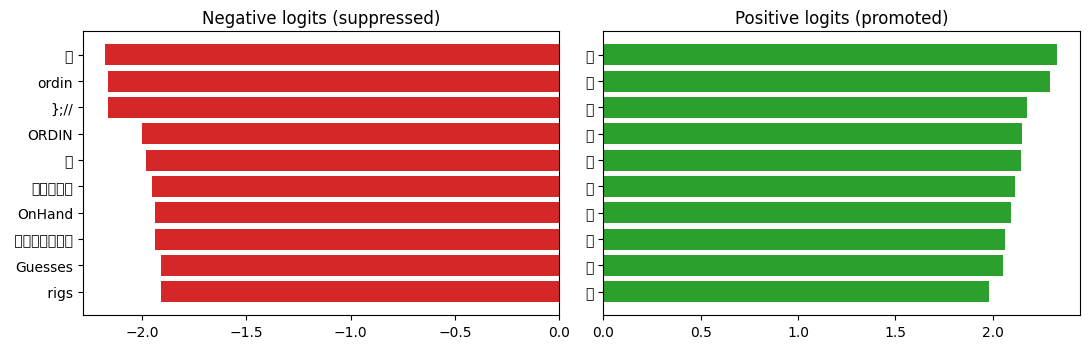

Top promoted tokens: ['🍇', '🍐', '🍊', '🍉', '🍎', '🍈', '🍑', '🥝', '🍏', '🍌']


In [3]:
base = model.model
normw = base.norm.weight.detach().float().to(DEV)             # final RMSNorm gain (Gemma: 1+w)
W_U   = base.embed_tokens.weight.detach().float().T.to(DEV)   # tied unembedding [d_model, vocab]

d = sae.W_dec[LATENT].float() * (1.0 + normw)
logit_w = d @ W_U                                             # [vocab]

k = 10
pos_v, pos_i = logit_w.topk(k)
neg_v, neg_i = logit_w.topk(k, largest=False)
pos = [tok.decode([i]) for i in pos_i.tolist()]
neg = [tok.decode([i]) for i in neg_i.tolist()]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].barh(range(k), neg_v.flip(0).cpu(), color="tab:red");   ax[0].set_yticks(range(k)); ax[0].set_yticklabels(neg[::-1]); ax[0].set_title("Negative logits (suppressed)")
ax[1].barh(range(k), pos_v.flip(0).cpu(), color="tab:green"); ax[1].set_yticks(range(k)); ax[1].set_yticklabels(pos[::-1]); ax[1].set_title("Positive logits (promoted)")
plt.tight_layout(); plt.show()
print("Top promoted tokens:", pos)


The positive logits are **fruit emojis** — 🍇 🍐 🍊 🍉 🍎 … — so at the output level too this
reads as a "fruit" feature: when it fires it leans the model *slightly* toward fruit emoji (only
slightly — see the modest ±2.3 range in Panel B). Our reconstructed values match Neuronpedia's
`pos_str` to two decimals, because we fold the RMSNorm gain exactly as they do.

## Panel B — Logits histogram & "logit effect range"

The little histogram under the logit tables is just the **distribution of those vocab logit
weights** across all ~262k tokens. It's near-symmetric and centered at zero; the **range**
(min → max) is the dashboard's "logit effect" span. A heavy, lopsided tail means a latent
strongly pushes a coherent set of tokens; a narrow blob means little direct output effect. At
**±2.3**, 7447 is on the modest side — a mid-layer feature whose effect is mostly routed through
the later layers, not written straight to the logits.


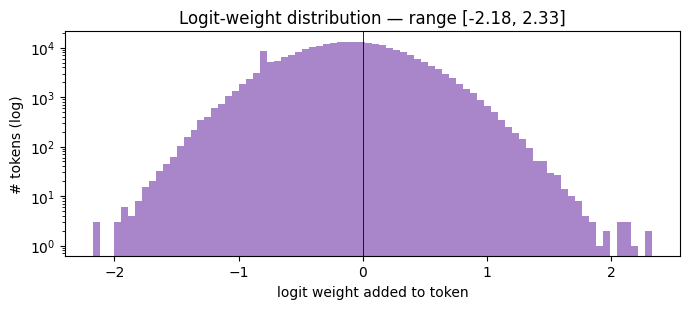

logit effect range: -2.176 … 2.332   (Neuronpedia: -2.176 … +2.333)


In [4]:
lw = logit_w.cpu().numpy()
plt.figure(figsize=(7, 3.2))
plt.hist(lw, bins=80, color="tab:purple", alpha=0.8)
plt.axvline(0, color="k", lw=.6)
plt.title(f"Logit-weight distribution — range [{lw.min():.2f}, {lw.max():.2f}]")
plt.xlabel("logit weight added to token"); plt.ylabel("# tokens (log)"); plt.yscale("log")
plt.tight_layout(); plt.show()
print(f"logit effect range: {lw.min():.3f} … {lw.max():.3f}   (Neuronpedia: -2.176 … +2.333)")


## Panel C — Activation density

The header's **activation density** (Neuronpedia: `frac_nonzero ≈ 1.05%`) is simply *the fraction
of tokens on which the latent fires*, and the orange histogram is the distribution of its
**positive** activation values. We estimate both by streaming a text corpus (a slice of The Pile,
the same distribution GemmaScope trained on) through model + SAE and collecting latent 7447's
activations. We **drop the BOS token**, whose residual is a huge outlier that would distort
everything.


Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

236370 tokens | activation density = 1.332%   (Neuronpedia: 1.05%)


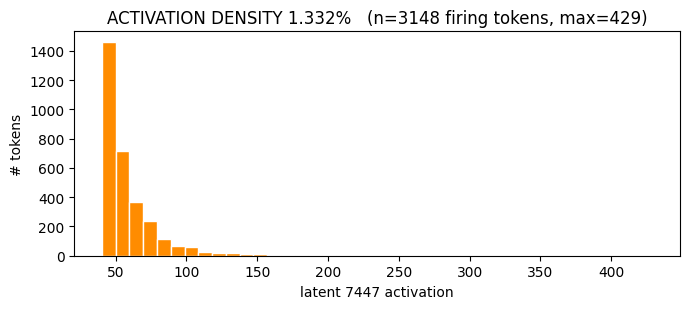

In [5]:
from datasets import load_dataset
ds = load_dataset("monology/pile-uncopyrighted", split="train", streaming=True); it = iter(ds)
def next_texts(n):
    out = []
    while len(out) < n:
        ex = next(it)
        if len(ex["text"]) > 200: out.append(ex["text"])
    return out

SEQ, BATCH, NBATCH = 128, 64, 30
acts_L, seq_records, n_tok = [], [], 0
for _ in range(NBATCH):
    enc = tok(next_texts(BATCH), return_tensors="pt", truncation=True, max_length=SEQ, padding="max_length")
    ids = enc.input_ids.to(DEV); am = enc.attention_mask.to(DEV)
    a = sae.encode(resid_of(ids, am))[..., LATENT]          # [B, T]
    for i in range(ids.shape[0]):
        m = am[i].bool() & (ids[i] != tok.bos_token_id)      # keep real tokens, drop pads + BOS
        av = a[i][m]; acts_L.append(av.cpu()); n_tok += int(m.sum())
        seq_records.append((av.max().item(), ids[i][m].cpu().tolist(), av.cpu().tolist()))
acts_L = torch.cat(acts_L)
density = (acts_L > 0).float().mean().item()
print(f"{n_tok} tokens | activation density = {density:.3%}   (Neuronpedia: 1.05%)")

pos = acts_L[acts_L > 0].numpy()
plt.figure(figsize=(7, 3.2))
plt.hist(pos, bins=40, color="darkorange", edgecolor="white")
plt.title(f"ACTIVATION DENSITY {density:.3%}   (n={len(pos)} firing tokens, max={acts_L.max():.0f})")
plt.xlabel("latent 7447 activation"); plt.ylabel("# tokens")
plt.tight_layout(); plt.show()


Our density (~1.3%) is close to Neuronpedia's 1.05% — a touch higher because our short 128-token
windows over-weight fruit-dense passages (a different, smaller corpus slice). The activation histogram has the same shape as the dashboard's:
a big pile of small activations and a long tail of strong ones.


## Panel D — Top activating examples (with the token heatmap)

The centerpiece of any dashboard: the **sequences where the latent fires hardest**, with each
token shaded by its activation. This is usually the single most informative panel for guessing
what a feature means. We sort our collected sequences by their peak activation and render the top
few, colouring every token by its activation (this is exactly the heatmap Neuronpedia draws).


In [6]:
def heatmap_html(records, top_n=8, ctx=12):
    vmax = max(r[0] for r in records)
    rows = []
    for maxact, ids_row, avals in sorted(records, key=lambda r: -r[0])[:top_n]:
        j = int(np.argmax(avals)); lo, hi = max(0, j-ctx), min(len(ids_row), j+ctx+1)
        spans = []
        for k in range(lo, hi):
            t = tok.decode([ids_row[k]]).replace("\n", "⏎")
            alpha = max(0.0, avals[k]) / vmax
            style = f"background:rgba(255,140,0,{alpha:.3f});" + ("font-weight:700;outline:1px solid #c60;" if k == j else "")
            spans.append(f"<span style='{style}padding:1px 0'>{t}</span>")
        rows.append(f"<tr><td style='text-align:right;color:#888;padding-right:8px'>{maxact:6.1f}</td>"
                    f"<td style='font-family:monospace;white-space:pre-wrap'>{''.join(spans)}</td></tr>")
    return HTML("<table style='border-collapse:collapse'>"
                "<tr><th>act</th><th style='text-align:left'>sequence (peak token outlined)</th></tr>"
                + "".join(rows) + "</table>")

display(heatmap_html(seq_records, top_n=8))


act,sequence (peak token outlined)
429.1,"and poultry, seafood, milk and dairy products including cheese, fruit, vegetables and vegetable oil-based products from the U."
324.6,Q:⏎⏎Apple rejected an app that for use on non public api where there
320.8,"Suplumfiftythree’ is characterized by having large, juicy fruit with black skin and red flesh. The fruit of the new"
298.1,Apple stores your Siri queries for up to two years⏎⏎Apple keeps
298.1,Apple Releases macOS Mojave 10.14.5 Beta
272.4,for Windows and Linux. There is also an upcoming version for Apple users that has yet to be released
272.1,zone. It is available now via Google Playstore and the Apple store.⏎⏎The app launched in Korea in 20
272.0,Introduction⏎⏎Replace the Oil with Unsweetened Applesauce to make these Waffles perfect in taste as well as


Now the honest twist. Yes, it fires on fruit (the sanity check lit up on bananas, grapes and the
emojis) — but scan the actual top rows: **most peak on "Apple" the *company*** (macOS, Siri, the
App Store), not the fruit. So 7447 blends a real fruit sense with the surface token "apple",
company and all. That's the **interpretability illusion** live: the fruit-emoji logits and a quick
glance make it look like a clean "fruit" detector, while the max-activating panel shows the messier
truth. Only hypothesis-testing (ablation, steering) pins down the real trigger.

## Panel E — Top features by decoder cosine similarity

The dashboard's "similar features" list ranks other latents by the **cosine similarity of their
decoder directions**, $\cos(W_{\text{dec}}[i], W_{\text{dec}}[j])$. Nearby latents tend to be
semantically related — this is how you spot **feature splitting** (one concept sliced into several
fine-grained latents) and **feature absorption**. Let's find 7447's neighbours and check what
*they* promote via the same logit lens.


In [7]:
Wd = F.normalize(sae.W_dec.float(), dim=-1)
cos = Wd[LATENT] @ Wd.T
vals, idx = cos.topk(9)                      # [0] is itself
def top_tokens(i, k=6):
    dl = (sae.W_dec[i].float() * (1.0 + normw)) @ W_U
    return [tok.decode([t]) for t in dl.topk(k).indices.tolist()]
print(f"decoder-cosine neighbours of latent {LATENT}:")
for v, i in zip(vals[1:].tolist(), idx[1:].tolist()):
    print(f"  latent {i:5d}  cos={v:.3f}   promotes → {top_tokens(i)}")


decoder-cosine neighbours of latent 7447:
  latent 10116  cos=0.169   promotes → ['𝚕', '𝚍', '𝚊', 'يبة', ' Defenders', '𝚜']
  latent  4613  cos=0.163   promotes → ['<bos>', ' entgegen', '고사', '阌', '른', '땄']
  latent  7442  cos=0.153   promotes → ['a', 'i', 'ه', 'া', 'й', 'aing']
  latent  1111  cos=0.148   promotes → ['<bos>', 'ী', 'th', '\uf0e5', 'CGFloat', 'वीं']
  latent  9654  cos=0.147   promotes → ['ত্ব', '𝘦', '颊', 'ार्किक', '袢', '𝕣']
  latent 15597  cos=0.145   promotes → ['۰۰', '𝘭', '𝗹', 'dır', 'י', '𝘴']
  latent  3318  cos=0.145   promotes → ['u', '不及', 'reverse', 'ตรฐาน', 'pling', ' undone']
  latent  9105  cos=0.142   promotes → [' المل', ' ألف', ' والذي', ' Eg', ' شنو', ' Aks']


Here's an honest result worth dwelling on: 7447's **top decoder cosine is only ~0.17** — it has
*no* close decoder twins in this SAE. Its direction is fairly **isolated**, which is what you'd
expect for a crisp, well-separated concept like "fruit". This is exactly when the panel is most
useful *by its absence*: on features that **do** split (say, a generic "number" feature that's
been carved into "years", "prices", "list indices"), you'd instead see a tight cluster of
high-cosine (0.4–0.8) neighbours that all promote related tokens. Low cosine here = one clean
feature, not a shattered one. (Neuronpedia doesn't pre-compute this list for this SAE, so it's a
panel we add ourselves — cheap, since it's weights-only.)


## What we skipped, and why

- **DFA (Direct Feature Attribution).** On *attention*-SAE dashboards there's an extra panel
  showing which **source tokens** an attention feature reads from. Ours is a *residual-stream*
  SAE, so there's no attention pattern to attribute — DFA doesn't apply here.
- **Autointerp / the text explanation** ("this feature fires on fruit"). That label is generated
  by an **LLM** reading the max-activating-examples panel we just built, then optionally *scored*
  by predicting activations on held-out text. It's a whole pipeline of its own; we sketch it at
  the end of Part 4.
- **Steering / test panel.** Neuronpedia lets you *add* the feature direction to a forward pass
  and watch the output change (e.g. steer toward fruit) — we have the ingredient
  ($W_{\text{dec}}[i]$); wiring up generation is a short exercise.

## Recap & what's next

Every panel on that dashboard is a simple function of **(a) the SAE weights** — top/negative
logits, the logits histogram, cosine neighbours — or **(b) the SAE run over a corpus** —
activation density and the max-activating-examples heatmap. Nothing is magic; you now know how to
compute all of it, and you verified it against the real page for the fruit feature.

**Next → Part 4: Training our own JumpReLU SAE on Gemma 3 1B** at this same layer 13, from a Pile
subset — activation collection, the training loop with L0 targeting and dead-latent resampling,
evaluation (L0 / variance-explained / loss-recovered), and a look at the features it discovers.
